## CAN Decoding

### Setup Library

In [1]:
# auto-reload library if developing library functionalities
%reload_ext autoreload
%autoreload 2

# import libraries
from PandaCANDecoder.decoder import Decoder
from diagnostic_signal import Diagnostic

### Choose Signals
Choose signals for which to find a match. Each choice should be a list with the form `['arbid', 'message_start', (start_byte, end_byte), (start_bit, end_bit), scale, offset]`.

The `arbid` parameter is required. The `message_start` is optional, but it is helpful if one arbitration ID corresponds to different messages, e.g. $0\text{x}7\text{DA}$ corresponds to the current and the voltage of each battery. Specifying that the message begins with $04618\text{A}$, filters the messages to those that only correspond to the current of battery 1. If there is no specific message start, input an empty string ' '.

If no starting/ending points are chosen, defaults to $0$ and $-1$, respectively.

_Bytes are indexed starting from $1$, while bits are indexed starting from $0$._

Choose scale and offset. Defaults to $1$ and $0$, respectively.

In [12]:
# BYTES INDEXED STARTING AT 1
# BITS INDEXED STARTING AT 0
# signals = [['0x245', '', (3, 3), (0, -1), 0.5, 0],
#            ['7DA', '04618a', (4, 5), (0, -1), 0.01, -327.68],
#            ['7DA', '0x06 61 81', (6, 7), (0, -1), 0.1, 0]]
# signals = [['7DA', '0x066181', (6, 7), (0, -1), 0.1, 0]]
signals = [['7E4', '', (4,4),(0,-1),0.5,0]]

known_signals = [Diagnostic(*signal) for signal in signals]
first_bits_and_lengths = [signal.get_bits() for signal in known_signals]

### Import Data
Takes a path to a .csv file and creates signals based on that path. Columns for the .csv file should be 'TimeStampNs', 'PandaNum', 'MessageID', 'Bus', 'MessageLength', and 'Message'. 

A .csv file downloaded directly from VSpy3 will have a lot of extra information. The `vspy_processing` function in panda_preprocessing.py accepts a .csv file downloaded from VSpy3 and corrects the formatting. It creates a new .csv file with 'processing_' prepended to the file name. By default, it deletes the original file, but setting `remove=False` allows the original file to remain.

In [14]:
# all_data_path = 'can_data/processed_combined_data.csv'
all_data_path = 'can_data/2023_Hyundai_Ioniq5_processed_dat.csv'

for signal in known_signals:
    signal.set_data_path(all_data_path)

can_decoder = Decoder(all_data_path, full_csv=True) # Keep full_csv=True here

signal_decoders = [Decoder(signal.data_path, full_csv=False) for signal in known_signals] # Set full_csv False

In [15]:
# Generate message objects
can_decoder.generate_msgs()
for signal in signal_decoders:
    signal.generate_msgs()

Generating messages           : 100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 1165.73it/s]


In [16]:
# Print messages
# can_decoder.print_msgs()
for signal in signal_decoders:
    signal.print_msgs()

-----------------------------------
Message ID: {Panda Number: [Buses]}
-----------------------------------
Message 0x7E4: {0: [0]}


### Generate Time Series Data
`can_decoder.generate_msg_ts_data` will generate message time series data for all message IDs. These get saved as numpy `uint64` arrays to the directory `./all_time_series_msgs/{msg_id}.npy` for fast reading. If the data needs to be saved for the first time, this step should take about $8$ seconds. If the data has been saved previously, the `rewrite` argument should be set to `False`. 

`signal.generate_msg_ts_data` will generate message time series data only for the message IDs chosen above. This should be fast regardless regardless of whether or not the data has already been saved previously.

In [17]:
# Saved as numpy `uint64` array to `./all_time_series_msgs/{msg_id}.npy` for fast reading

# force write all .npy files
can_decoder.generate_msg_ts_data(rewrite=False)
print('*'*88)
for signal in signal_decoders:
    signal.generate_msg_ts_data(full_csv=False, rewrite=True)

Generating message data       :   0%|                                                          | 0/562 [00:00<?, ?it/s]


OverflowError: int too big to convert

In [7]:
# # Calculate predicted signals
can_decoder.calculate_signals(
        tokenization_method='conditional_bit_flip',
        signedness_method='msb_classifier',
        alpha1=0.01,
        alpha2=0.5,
        gamma1=0.2)
for i, signal in enumerate(signal_decoders):
    signal.calculate_ref_signal(
        start_bit=first_bits_and_lengths[i][0],
        length=first_bits_and_lengths[i][1],
        factor=known_signals[i].scale,
        offset=known_signals[i].offset,
        gamma=0.2
    )

Generating signals            : 100%|███████████████████████████████████████████████| 104/104 [00:00<00:00, 132.65it/s]


### Reference PID Signal
This creates a bit flip probability chart for each message of interest. Each signal is represented by a different color. Signedness is represented by the shading, where shaded corresponds to twos complement and unshaded to unsigned.

It should be noted that creating these tables does take some time, somewhere around 5 seconds per plot. Most of the relevant information will also be visible when the signal matching is done, so plotting these tables can be skipped if desired.

_It should also be noted that these tables separate messages based only on the message ID and not the start of the message. Thus the table will be the exact same for battery 1 voltage as for battery 2 current. That is something that may be changeable in the future._

In [8]:
# Plot message decoding tool
# for signal in known_signals:
#     can_decoder.plot_message_from_id(signal.arbid)

### Plot signal data
Plot the signals corresponding to the arbitration IDs chosen previously.

_Note that the number at the end of the signal name for each signal changes $0$ i.e. 'SIG_BE_0', regardless of what the signal number was when plotted in the bit flip table. This does not impact anything else._

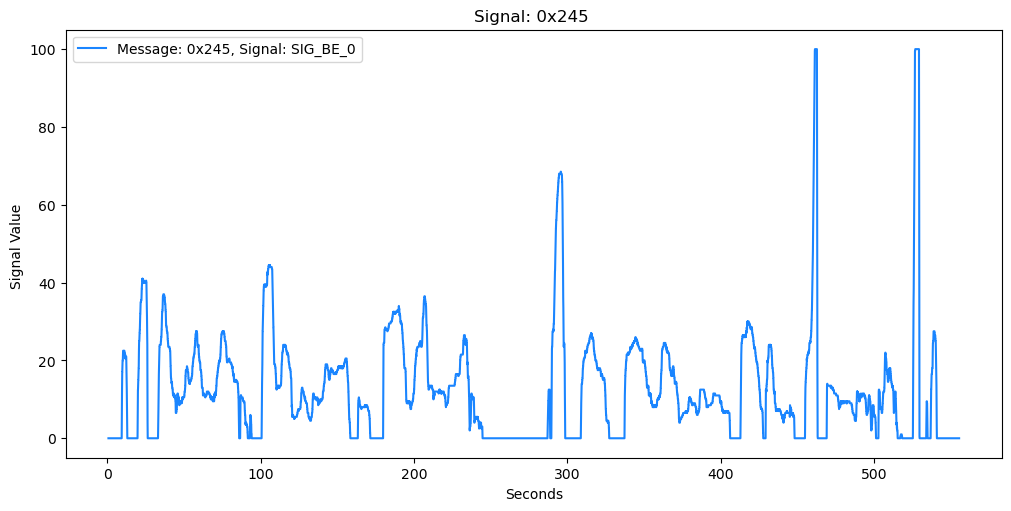

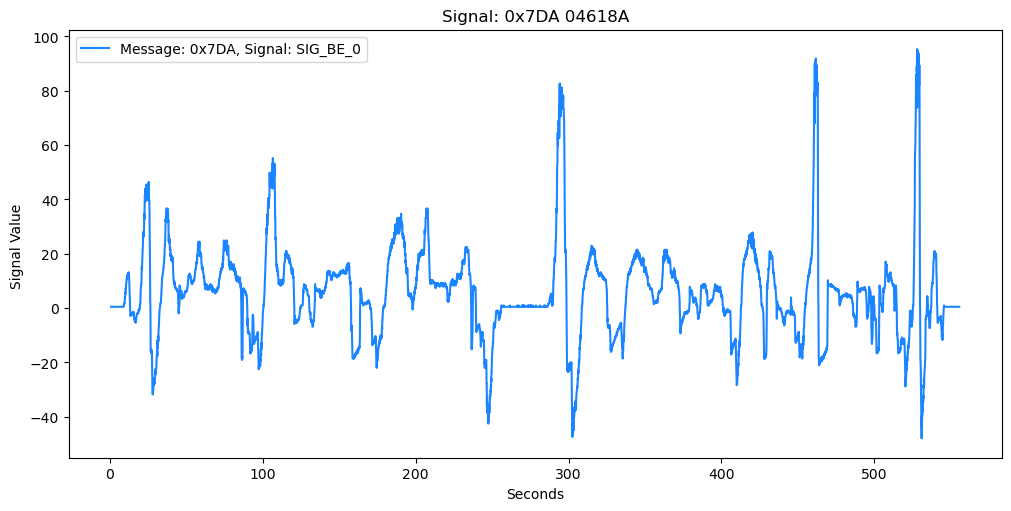

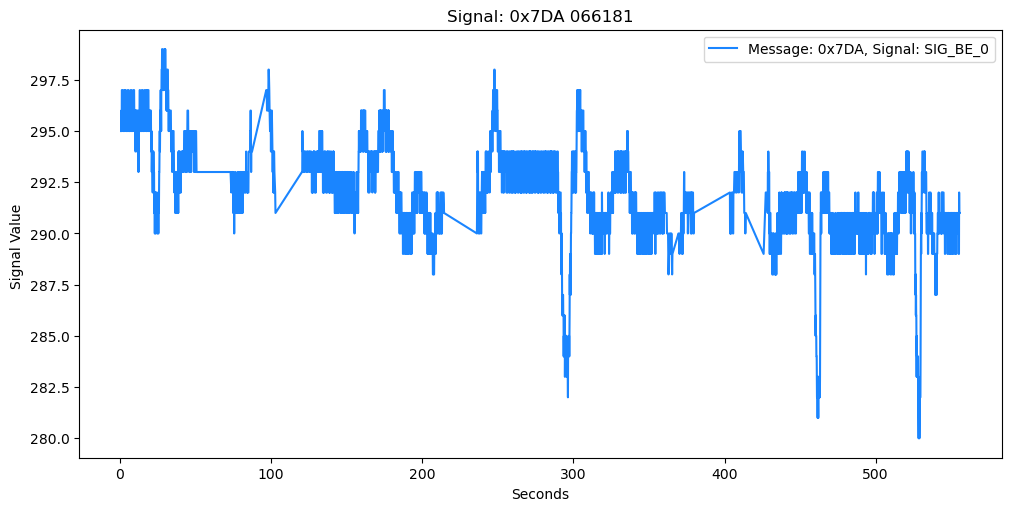

In [9]:
# Plot signal data
ref_signals = []
for i, signal in enumerate(signal_decoders):
    ref_signal = signal.get_signal(known_signals[i].arbid, 'SIG_BE_0')
    ref_signals.append(ref_signal)
    signal.plot_signal(ref_signal, known_signals[i].message_start)

### Signal Matching
This step finds signals that match the above signals beyond a specified threshold. That threshold can be adjusted by changing the value of `thresh`. Only the matches with the highest $R^2$ values will be shown. That number can be changed as well by changing the value of `num_matches`.

****************************************************************************************
Message: 0x245, Signal: SIG_BE_0
(Message: 0x361, Signal: SIG_BE_2, Message: 0x245, Signal: SIG_BE_0, LinearRegression(), 0.9992664693370591)


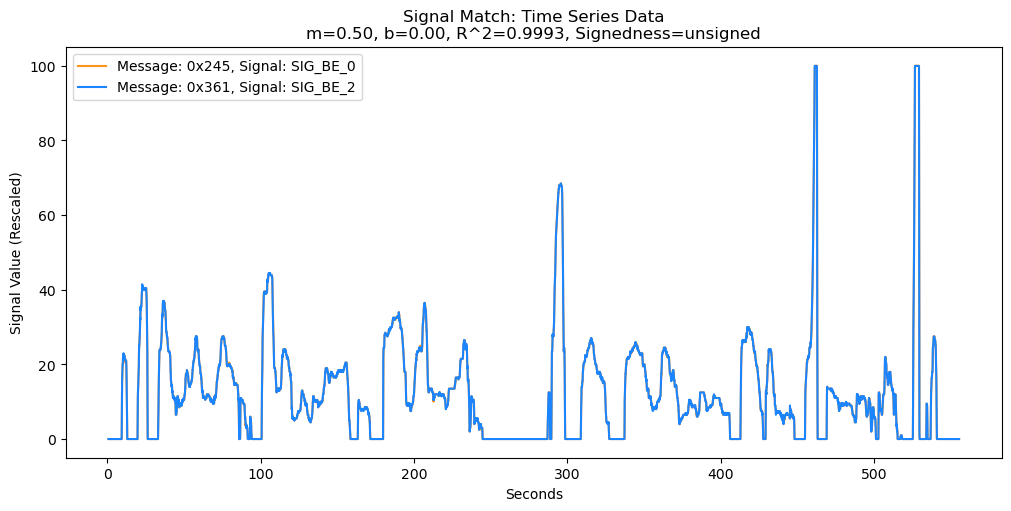

(Message: 0x361, Signal: SIG_LE_1, Message: 0x245, Signal: SIG_BE_0, LinearRegression(), 0.9992664693370591)


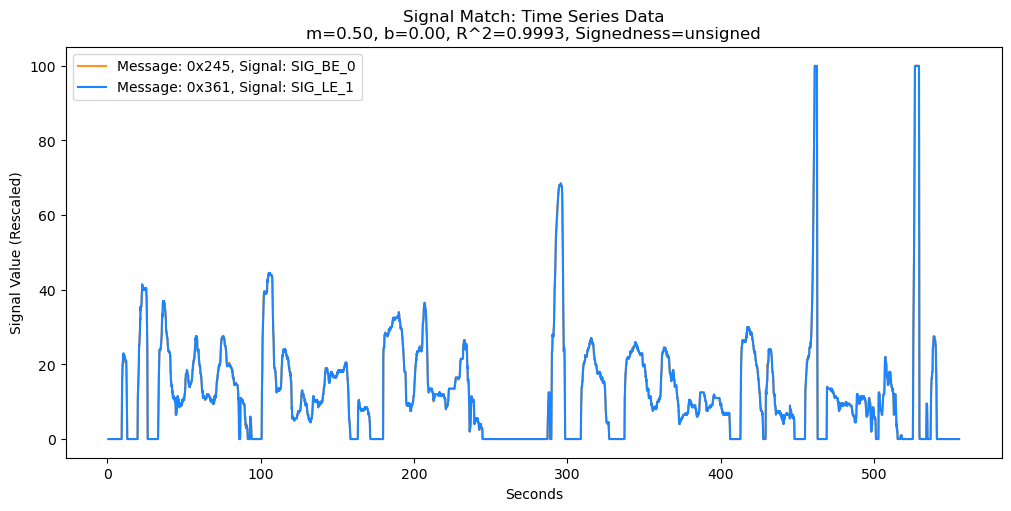

(Message: 0x49A, Signal: SIG_BE_1, Message: 0x245, Signal: SIG_BE_0, LinearRegression(), 0.9958929712904043)


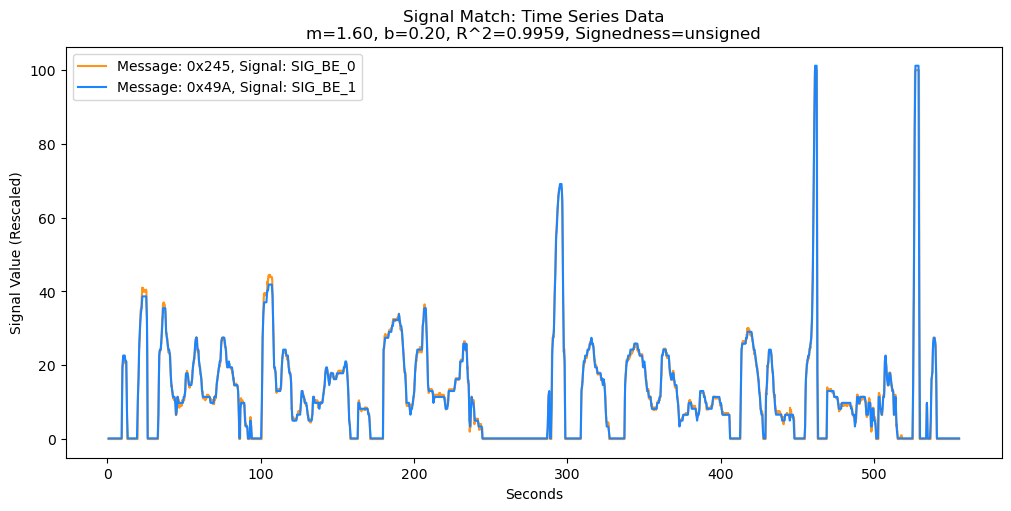

****************************************************************************************
Message: 0x7DA, Signal: SIG_BE_0
(Message: 0x49D, Signal: SIG_BE_6, Message: 0x7DA, Signal: SIG_BE_0, LinearRegression(), 0.9945258611848897)


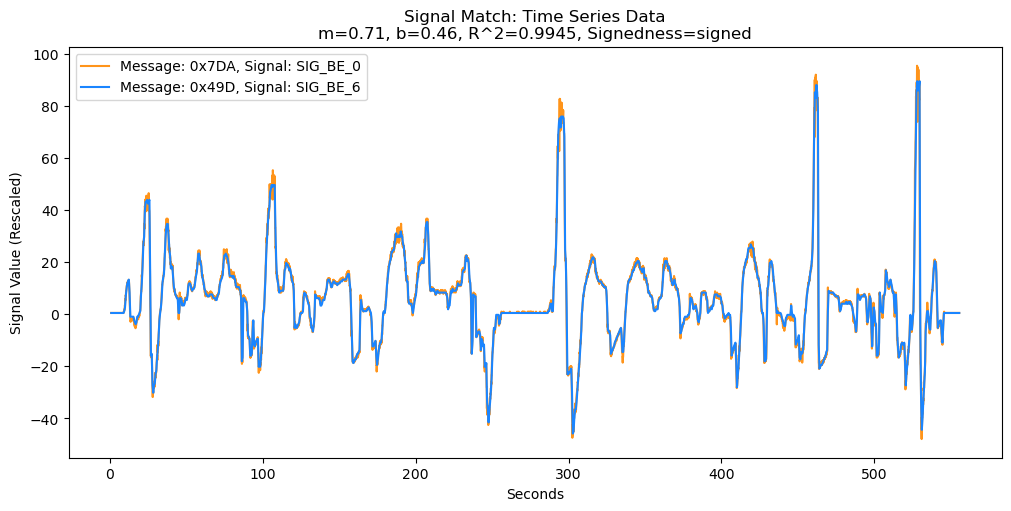

(Message: 0x49D, Signal: SIG_LE_1, Message: 0x7DA, Signal: SIG_BE_0, LinearRegression(), 0.9945258611848897)


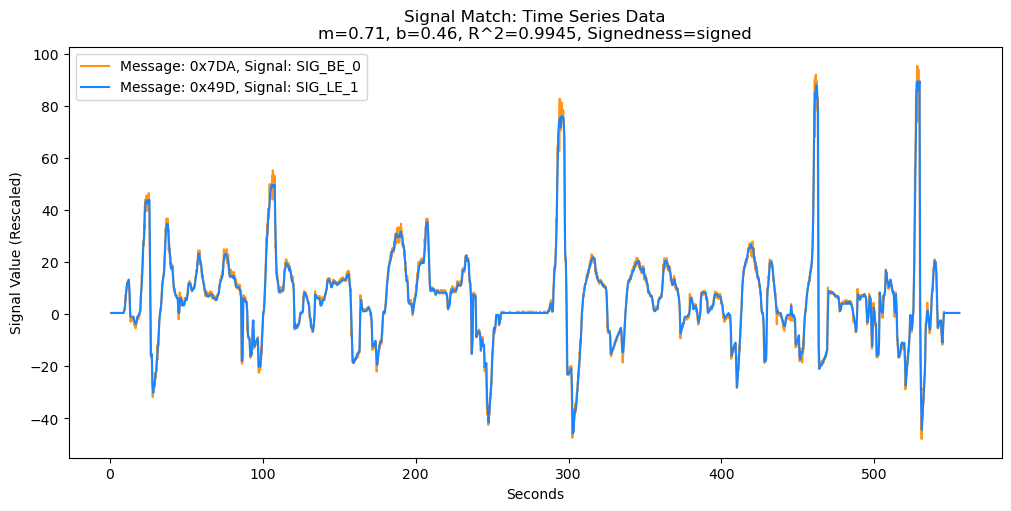

(Message: 0x49B, Signal: SIG_BE_4, Message: 0x7DA, Signal: SIG_BE_0, LinearRegression(), 0.9942795328974438)


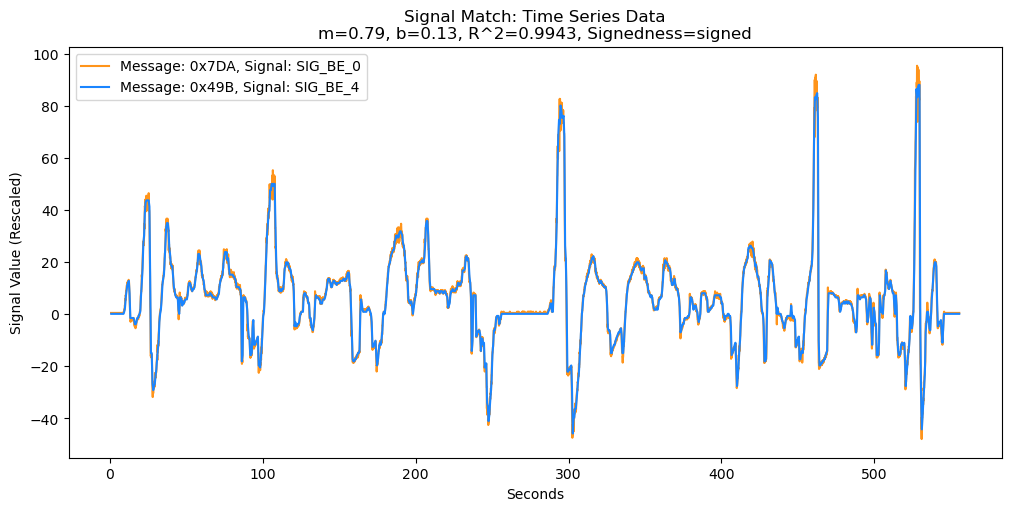

****************************************************************************************
Message: 0x7DA, Signal: SIG_BE_0
No more matches for signal Message: 0x7DA, Signal: SIG_BE_0 above threshold 0.95
Other potential matches include:
(Message: 0x49D, Signal: SIG_BE_5, Message: 0x7DA, Signal: SIG_BE_0, LinearRegression(), 0.38522235518193204)


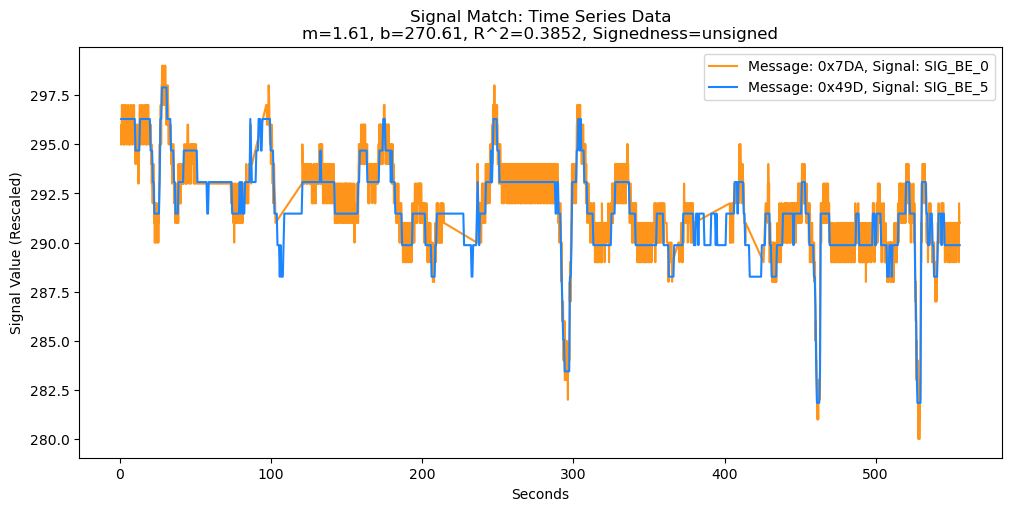

(Message: 0x49D, Signal: SIG_LE_3, Message: 0x7DA, Signal: SIG_BE_0, LinearRegression(), 0.3748284912878162)


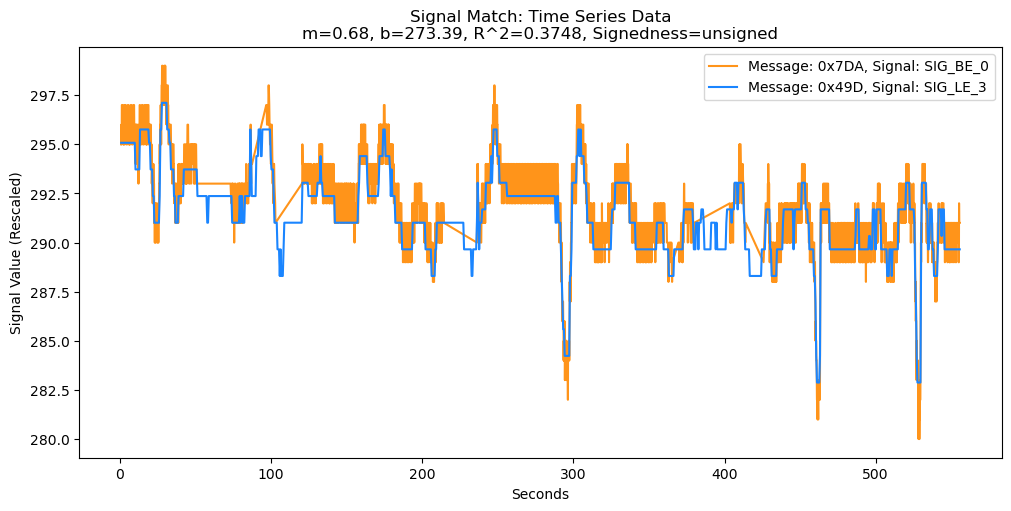

(Message: 0x49B, Signal: SIG_BE_1, Message: 0x7DA, Signal: SIG_BE_0, LinearRegression(), 0.3590807067955587)


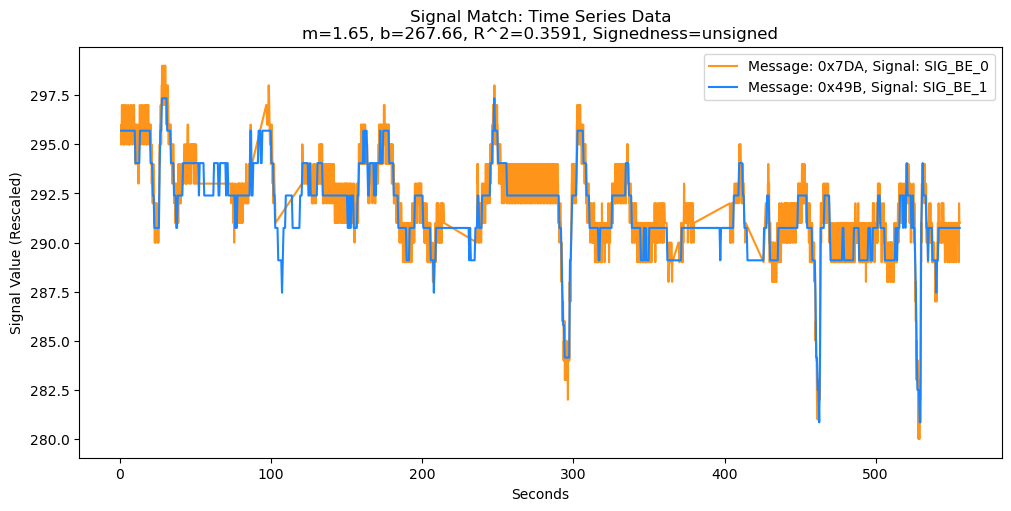

In [10]:
# Signal matching
matches = []
for ref_signal in ref_signals:
    print('*'*88)
    print(ref_signal)
    matches.append(can_decoder.find_signal_match(ref_signal, num_matches=3, thresh=0.95, plot=True))

### Plot Message for Candidate Messages
For each match that was plotted above, the CAN message is shown. Just as before, the colors show where signals end the shaded portions are where two's complement is used. 

Match for 0x245: 0x361, SIG_BE_2


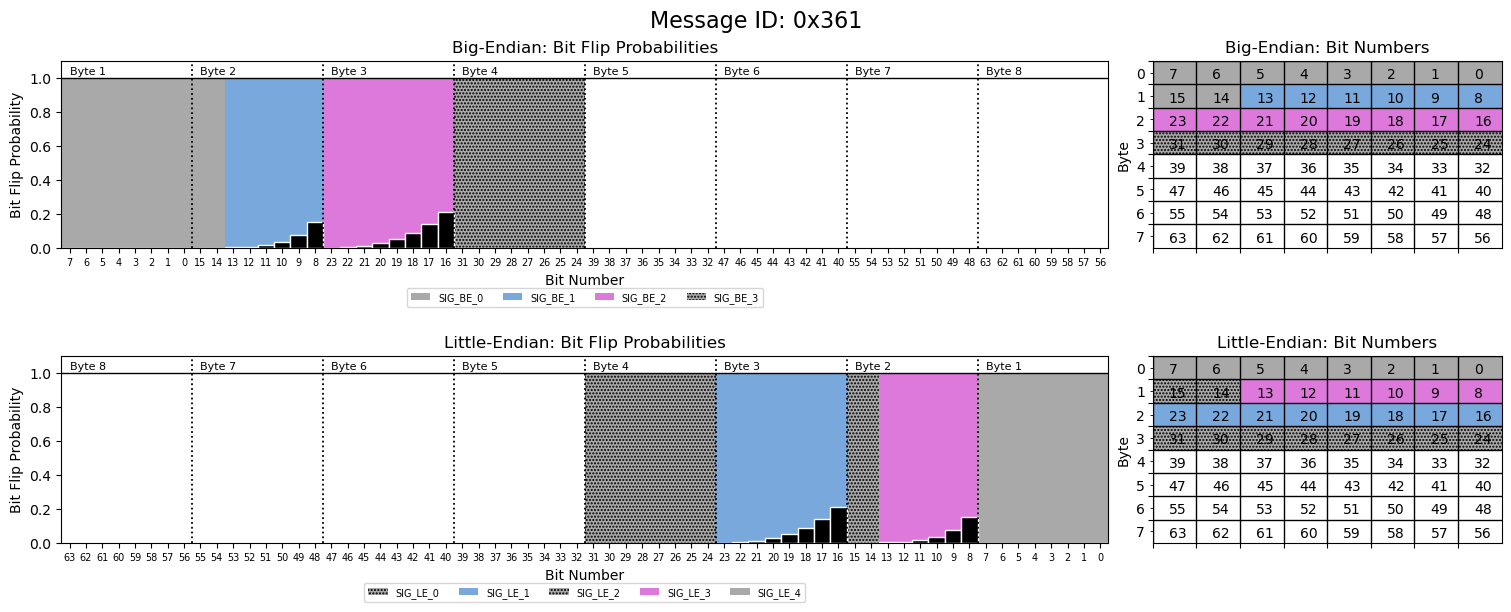

Match for 0x245: 0x361, SIG_LE_1


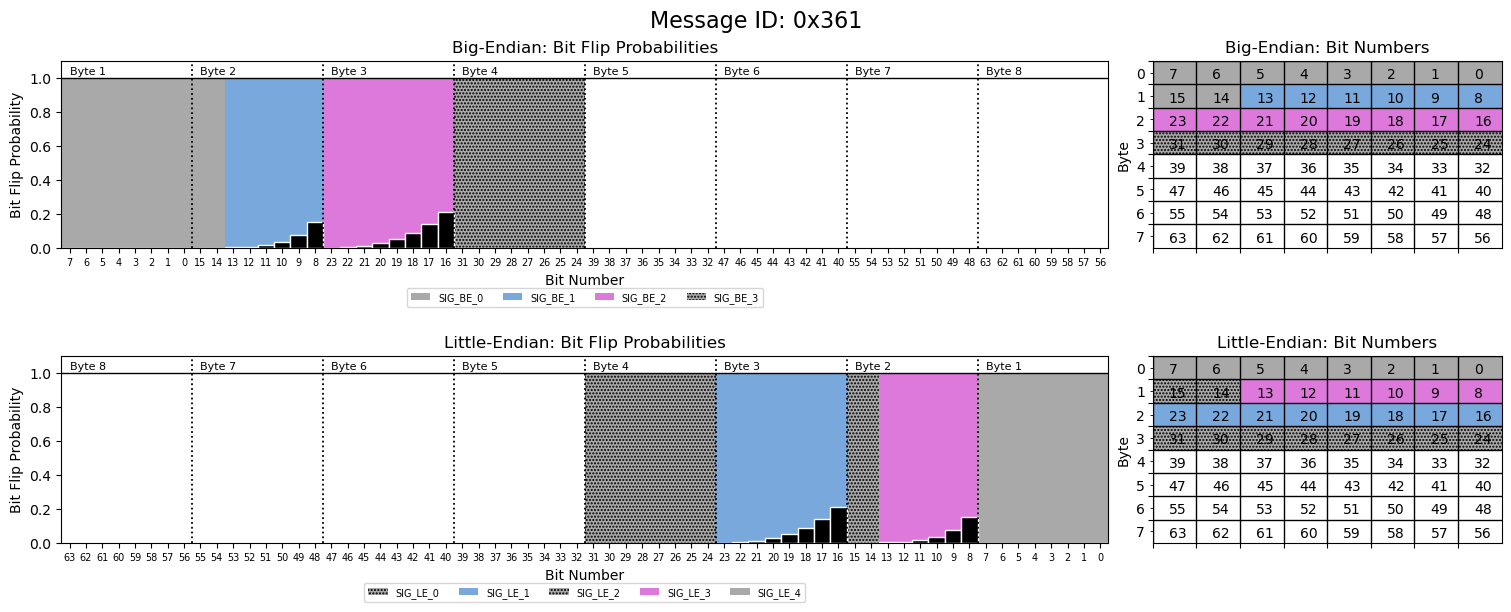

Match for 0x245: 0x49A, SIG_BE_1


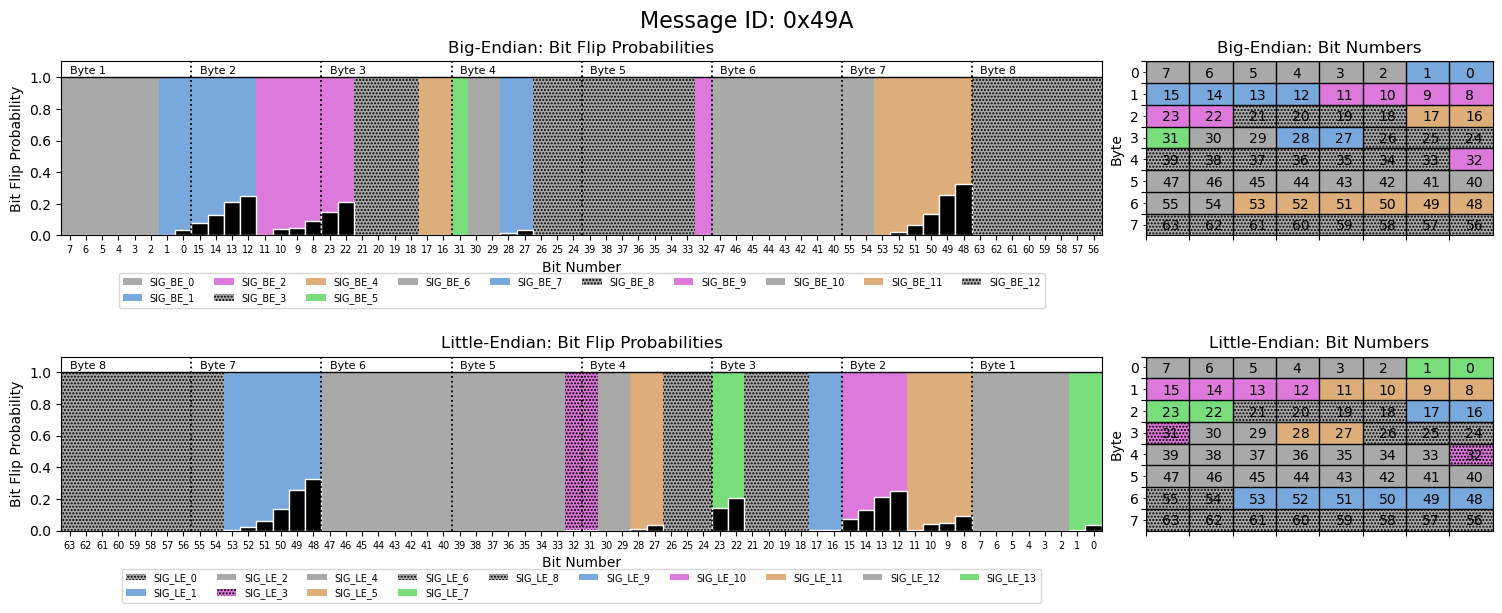

Match for 0x7DA: 0x49D, SIG_BE_6


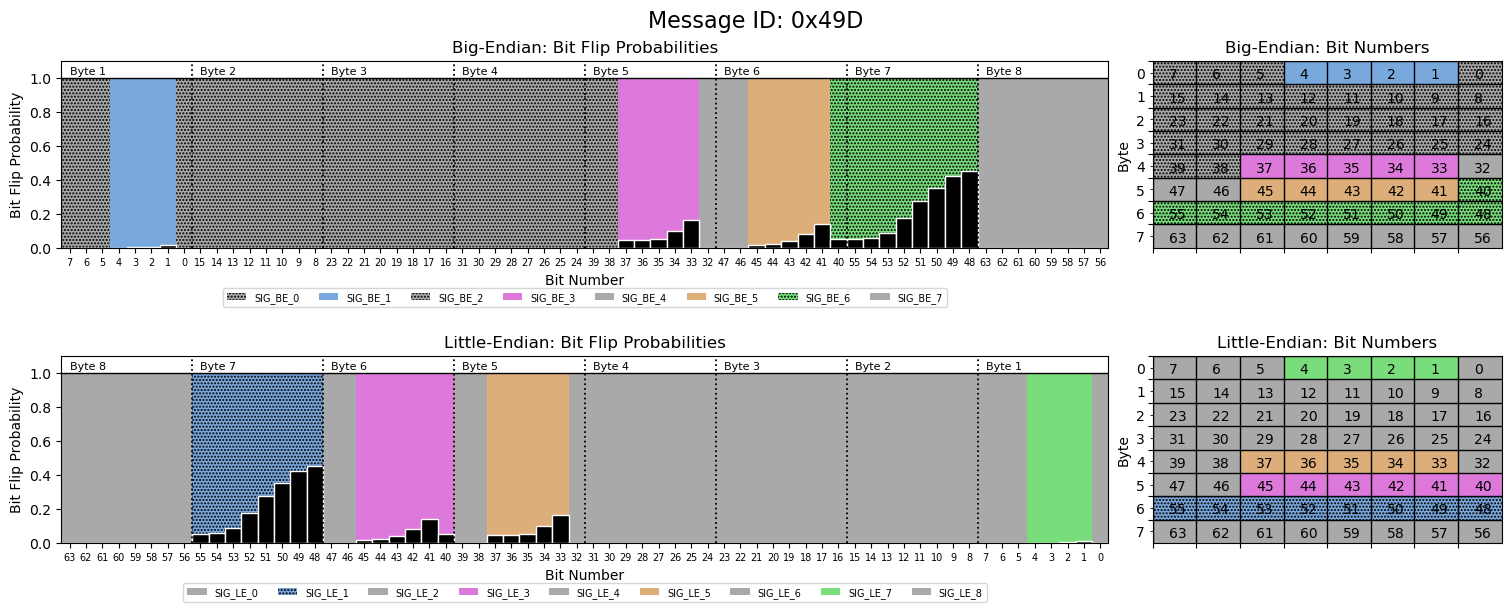

Match for 0x7DA: 0x49D, SIG_LE_1


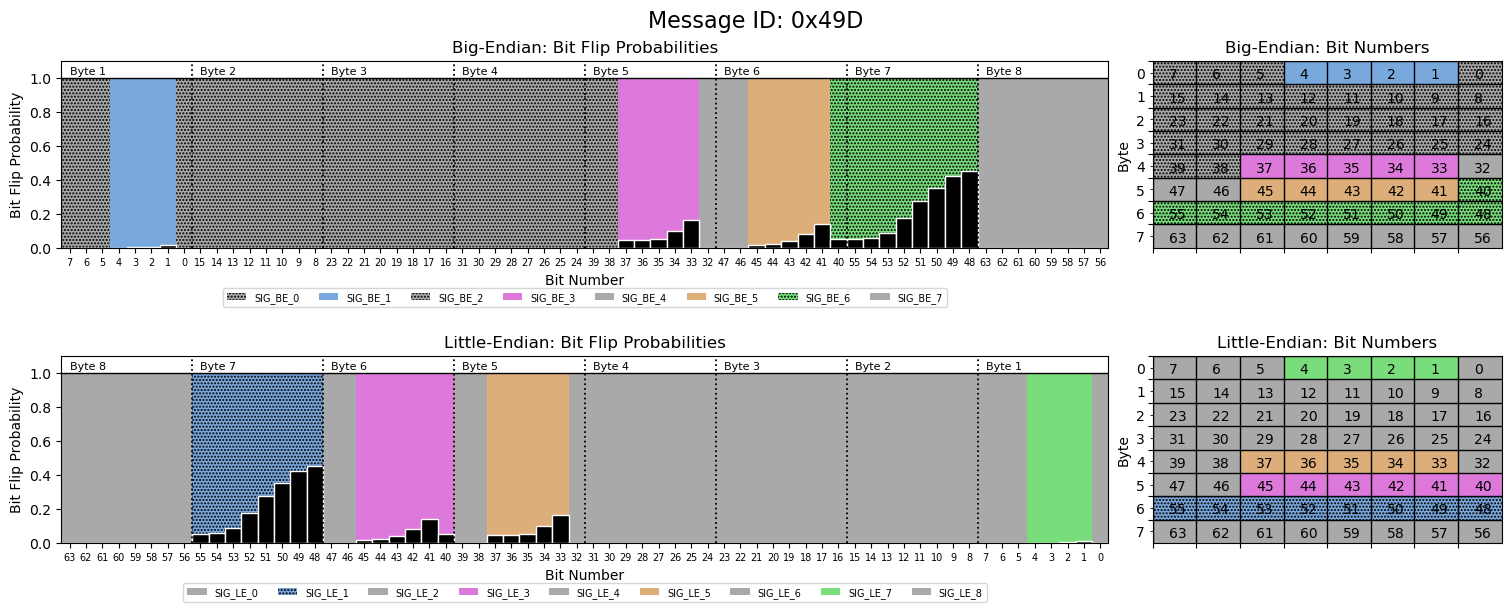

Match for 0x7DA: 0x49B, SIG_BE_4


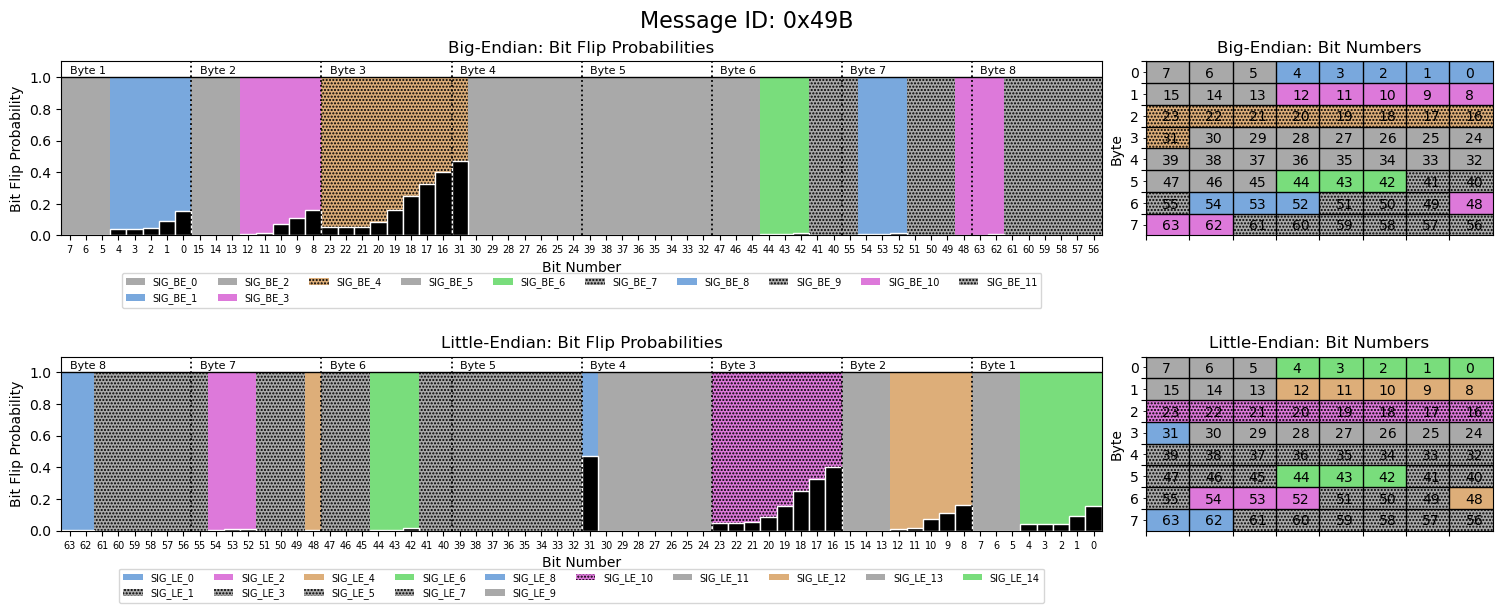

Match for 0x7DA: 0x49D, SIG_BE_5


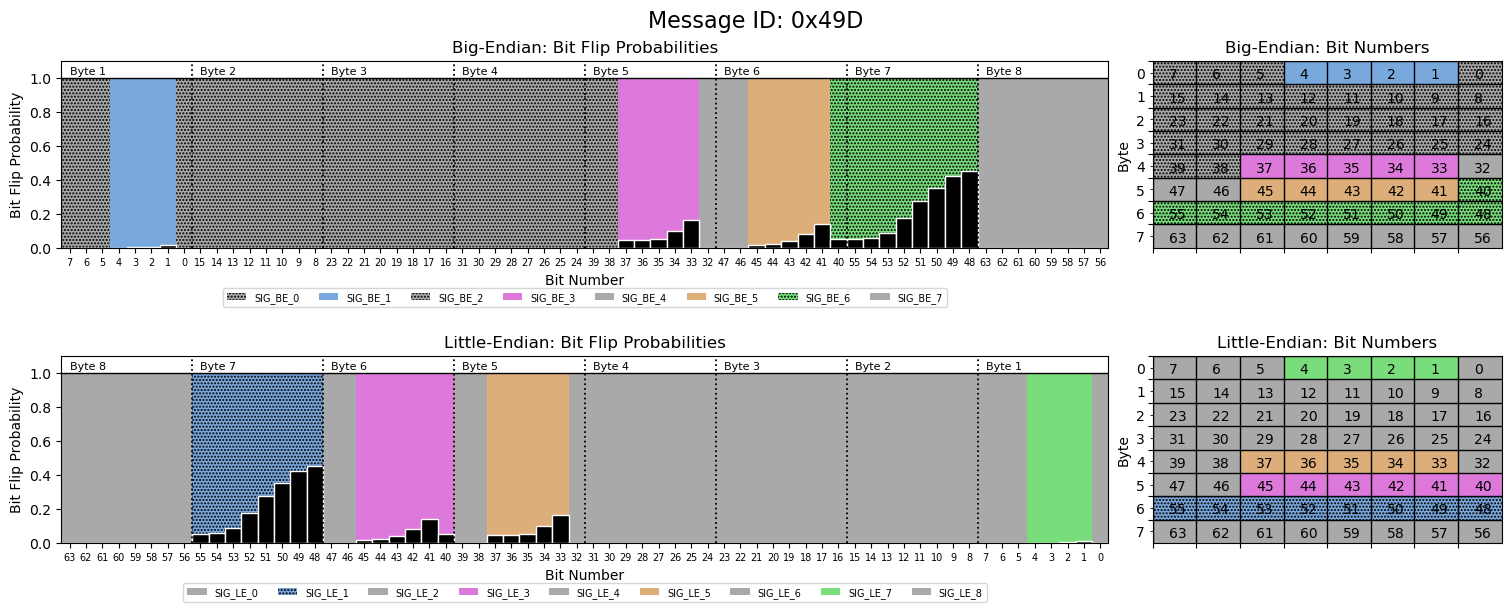

Match for 0x7DA: 0x49D, SIG_LE_3


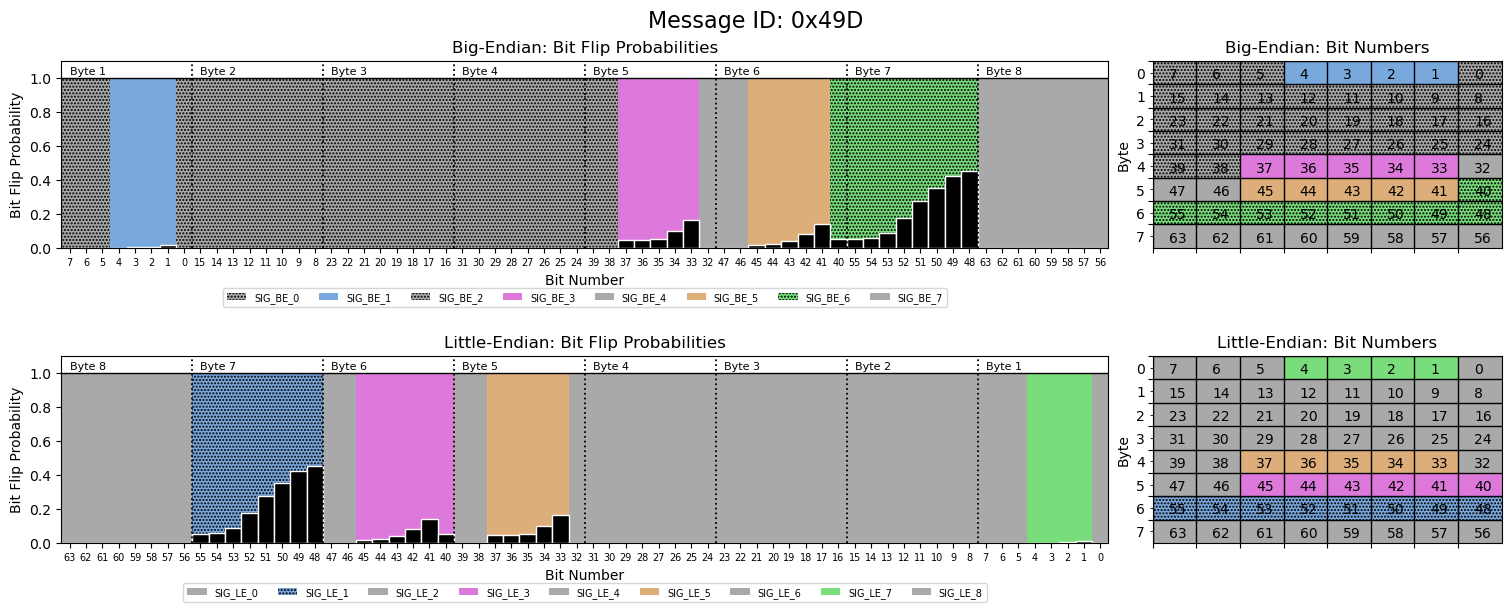

Match for 0x7DA: 0x49B, SIG_BE_1


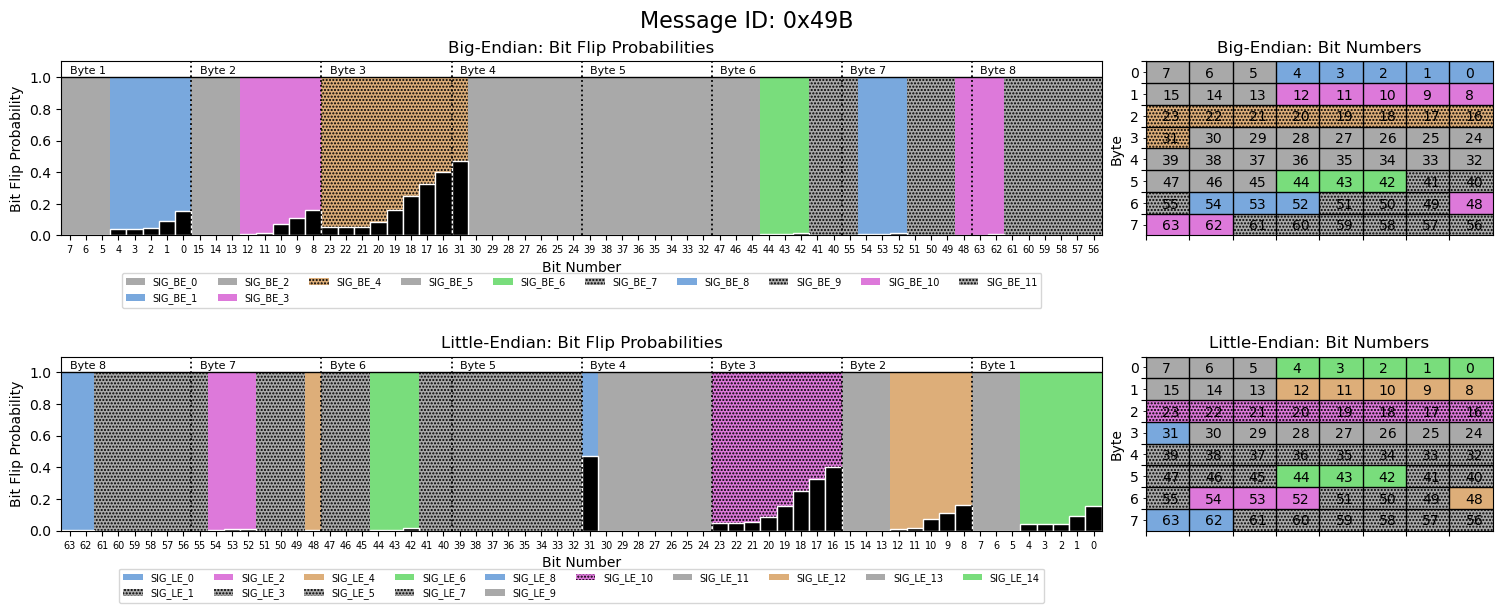

In [11]:
for i, match in enumerate(matches):
    if len(match) > 0:
        for submatch in match:
            print(f'Match for {submatch[1].msg.msg_id}: {submatch[0].msg.msg_id}, {submatch[0].name}')  
            can_decoder.plot_message_from_id(submatch[0].msg.msg_id)
    else:
        print(f'No matches found for {known_signals[i].arbid} {known_signals[i].message_start[2:]}')